In [264]:
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration

from mGST.low_level_jit import cost_function_jax_mps, contract_mps_all_povm, gradient_povm_mps_jit
from mGST.additional_fns import perturbed_target_init, sampled_measurements, random_seq_design
from mGST.utility_functions_comparisons import riemannian_metric, random_tangent_vector, get_compressed_rep_from_mgst_output, get_compressed_rep_mgst_cholesky, tensor_to_isometry, isometry_to_tensor, is_in_tangent_space, riemannian_hessian_vector_povm_jax, hvp, is_isometry, canonical_gradient, gradient_and_operator_tensors_to_stiefel, project_onto_tangent_space
from mGST.algorithm import riemannian_hessian_povm


import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit.library import CZGate, RGate
import pickle

TangentVector = jnp.ndarray
Isometry = jnp.ndarray
Tensor = jnp.ndarray

backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup

In [ ]:
qubit_layouts = [[2,8], [4,10], [6,12], [15,23], [19,25], [21,27], [31,39], [30,35], [42,46], [44,48]]

gates = [QuantumCircuit(2, 0) for _ in range(7)]
gates[0].append(RGate(1e-9, 0), [0])
gates[1].append(RGate(0.5 * jnp.pi, 0), [0])
gates[2].append(RGate(0.5 * jnp.pi, 0), [1])
gates[3].append(RGate(0.5 * jnp.pi, jnp.pi / 2), [0])
gates[4].append(RGate(0.5 * jnp.pi, jnp.pi / 2), [1])
gates[5].append(RGate(0.5 * jnp.pi, 0), [0])
gates[5].append(RGate(0.5 * jnp.pi, 0), [1])
gates[6].append(CZGate(), [[0], [1]])
gate_labels = [
    "Idle",
    "Rx(pi/2):0",
    "Rx(pi/2):1",
    "Ry(pi/2):0",
    "Ry(pi/2):1",
    "Rx(pi/2)-Rx(pi/2):0-1",
    "CZ",
]

Q2_GST_EMERALD = GSTConfiguration(
    qubit_layouts=qubit_layouts,
    gate_set=gates,
    gate_labels = gate_labels,
    num_circuits=1000,
    shots=1000,
    rank=16,
    opt_method="GD",
    max_iterations = [140, 250],
    convergence_criteria=[4, 1e-4],
    parallel_execution = True,
    max_gates_per_batch = 35000
)

with open(data_path +'emerald_2q_parallel_qubits_44__48.pkl', 'rb') as function:
    data = pickle.load(function)
    
X_true = data["X_true"]
E_true = data["E_true"]
rho_true = data["rho_true"]

K_target = data["K_target"]
X_target = data["X_target"]
E_target = data["E_target"]
rho_target = data["rho_target"]

# dimensions
dim = rho_true.shape[0]
num_povm = E_true.shape[0]
num_gates = X_true.shape[0]
bsize = 30 * dim
# Getting the values to be initialized
kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(X_target, E_target, rho_target, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax_target = povm_psd_2q_target.conj().transpose(0, 2, 1) @ povm_psd_2q_target
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_target, kraus_tensor_2q_target.conj()).reshape((num_gates, dim**2, dim**2))

rho_target_matrix = rho_target.reshape(dim, dim)
povm_target_matrices = E_target.reshape(num_povm, dim, dim)

jnp.allclose(state_psd_2q_target @ state_psd_2q_target.conj().T, rho_target_matrix), jnp.allclose(povm_jax_target, povm_target_matrices), jnp.allclose(superop_kraus_test, X_target)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [11]:
state_mgst_true = rho_true.reshape(-1)
povm_mgst_true = E_true.reshape(num_povm, -1)

kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true  = get_compressed_rep_from_mgst_output(X_true, povm_mgst_true, state_mgst_true, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax = povm_psd_2q_true.conj().transpose(0, 2, 1) @ povm_psd_2q_true
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_true, kraus_tensor_2q_true.conj()).reshape((num_gates, dim**2, dim**2))

target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]

jnp.allclose(state_psd_2q_true @ state_psd_2q_true.conj().T, rho_true), jnp.allclose(povm_jax, E_true), jnp.allclose(superop_kraus_test, X_true)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [12]:
shots = 1000

N = 100  # Number of sequences
N_short = int(jnp.ceil(N / 2))
N_long = int(jnp.floor(N / 2))
meas_samples = 1e5  # Number of samples per sequences

# generate random numbers between 0 and $d^l - 1$
J = random_seq_design(num_gates, 1, 8, 14, N_short, N_long)
indices_list_2q = [indices[indices != -1] for indices in J]
# compute outcome probabilities
prob_matrix_exact = []
for indices in indices_list_2q:
    prob_matrix_exact.append(jnp.real(contract_mps_all_povm(kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true, indices)))
    
prob_matrix_exact = jnp.array(prob_matrix_exact).T
prob_matrix_2q_sampled = sampled_measurements(prob_matrix_exact, shots, seed=42)


In [27]:
kraus_rank = dim**2
kraus_init_mgst = perturbed_target_init(X_target, kraus_rank, seed=42)
x_init_mgst = jnp.einsum("ijkl,ijnm -> iknlm", kraus_init_mgst, kraus_init_mgst.conj()).reshape((num_gates, dim**2, dim**2))
povm_target_mgst = E_target.reshape(num_povm, -1)
rho_target_mgst = rho_target.reshape(-1)
init_mgst = [kraus_init_mgst, povm_target_mgst, rho_target_mgst]

In [40]:
povm_psd_init_jax, state_psd_init_jax = get_compressed_rep_mgst_cholesky(povm_target_mgst, rho_target_mgst)
kraus_tensor_init_jax = jnp.array(kraus_init_mgst)
povm_psd_init_mgst = np.array(povm_psd_init_jax)
state_psd_init_mgst = np.array(state_psd_init_jax)

# Jax JVP test
Is the result with the hessian from JAX the same as the one from mGST?

In [41]:
n = num_povm * dim
p = dim
povm_isometry = tensor_to_isometry(povm_psd_init_jax, n, p)

In [42]:
rhessian_tensor, rgradient_tensor = riemannian_hessian_povm(
    K=kraus_init_mgst,
    A=povm_psd_init_mgst,
    B=state_psd_init_mgst,
    y=prob_matrix_2q_sampled,
    J=indices_list_2q,
    return_gradient=True
)

rhessian_matrix = rhessian_tensor.reshape(2 * n * p, 2 * n * p)

In [ ]:
z1 = random_tangent_vector(x=povm_isometry, n=n, p=p, seed=1) 
hessian_z1 = rhessian_matrix @ jnp.vstack((z1, z1.conj())).reshape(-1)
hessian_z1 = hessian_z1[:n * p].reshape(n, p)  # we are getting only half of the vector
rnorm_z1 = riemannian_metric(z1, z1, x=povm_isometry, metric="canonical")
rnorm_hz1 = riemannian_metric(hessian_z1, hessian_z1, x=povm_isometry, metric="canonical")
print('Canonical Riemannian metrics:')
print('- Z1', rnorm_z1)
print('- H*Z1', rnorm_hz1)

Canonical Riemannian metrics:
- Z1 86.57777661682614
- H*Z1 0.023810639850759773


In [76]:
z1_tensor = z1.reshape(num_povm, dim, dim)
hessian_z1_jax = riemannian_hessian_vector_povm_jax(tangent_vector=z1_tensor, kraus_tensor=kraus_tensor_init_jax, povm_psd=povm_psd_init_jax, state_psd=state_psd_init_jax, indices_list=indices_list_2q, prob_matrix=prob_matrix_2q_sampled, metric="canonical")

Using JAX power


In [77]:
vector_1 = hessian_z1
vector_2 = hessian_z1_jax
print('Are they the same?', jnp.allclose(vector_1, vector_2))
print('With conjugate?', jnp.allclose(vector_1, vector_2.conj()))

test_metric_euclidean = riemannian_metric(vector_1, vector_2, x=povm_isometry, metric="euclidean")
test_metric_canonical = riemannian_metric(vector_1, vector_2, x=povm_isometry, metric="canonical")
print('Test metrics:')
print('- Euclidean:', test_metric_euclidean)
print('- Canonical:', test_metric_canonical)
print('- Same as with itself?', jnp.allclose(test_metric_canonical, rnorm_hz1))

Are they the same? True
With conjugate? False
Test metrics:
- Euclidean: 0.04573423638650684
- Canonical: 0.023810639850759777
- Same as with itself? True


**Answer**: Yes!

# Test if this provides a second order approximation

# 1. Cost function defined on $\mathrm{C}^{n \times p} \to \mathrm{R}$

In [193]:
f_povm = lambda povm: cost_function_jax_mps(
    kraus=kraus_tensor_init_jax,
    povm_psd=povm,
    state_psd=state_psd_init_jax,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    jit=True
    )

gradf_povm = lambda povm: gradient_povm_mps_jit(kraus_tensor_init_jax, povm, state_psd_init_jax,
    indices_list=indices_list_2q, prob_matrix=prob_matrix_2q_sampled) # 2df/dx

def euclidean_inner_product_tensor(tensor1:jnp.ndarray, tensor2:jnp.ndarray):
    """Euclidean inner product between two tensors.

    Equivalent to just taking the inner product, <tensor1, tensor2> = vec(tensor1).T vec(tensor2)
    """
    return jnp.real(jnp.einsum("i,i", tensor1.reshape(-1), tensor2.reshape(-1)))

def cost_function_euclidean(x:jnp.ndarray, t:float, z:jnp.ndarray):
    return f_povm(x + t * z)

def approximation_euclidean(x:jnp.ndarray, t:float, z:jnp.ndarray, order:int):
    """Euclidean approximation of the cost function.

    Equation:
        f(x + t * z) ≈ f(x) + t * <z, ∇f(x)> + (t^2 / 2) * <z, Hf(x)[z]>
        with:
        - <z1, z2> = Re(z1^T @ z2)
        - ∇f(x) = 2df/dx
        - Hf(x)[z] = 2(df/dxdx) z + 2(df/dx*dx) z*

    """
    gradient_x_jax, Dgradient_z = hvp(gradf_povm, x=x, z=z) # 2df/dx, 2 Hxx dx + 2 Hx*x dx*
    if order not in [1, 2]:
        raise ValueError("Only first and second-order approximation are implemented.")
    # Zero order term
    value = f_povm(x)
    # First order term
    # Equivalent expressions since we are taking the Real part and Re(z) = Re(z*)
    # value += t * euclidean_inner_product_tensor(z.conj(), gradient_x_jax.conj())
    value += t * euclidean_inner_product_tensor(z, gradient_x_jax)
    # Second order term
    if order == 2:
        value += (t**2 / 2) * euclidean_inner_product_tensor(z, Dgradient_z)
    return value

In [152]:
x = povm_psd_init_jax
ts = np.arange(-0.02, 0.021, 0.001)
cost_function_t = [cost_function_euclidean(x, t, z1_tensor) for t in ts]
first_order_t = [approximation_euclidean(x, t, z1_tensor, order=1) for t in ts]
second_order_t = [approximation_euclidean(x, t, z1_tensor, order=2) for t in ts]

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JA

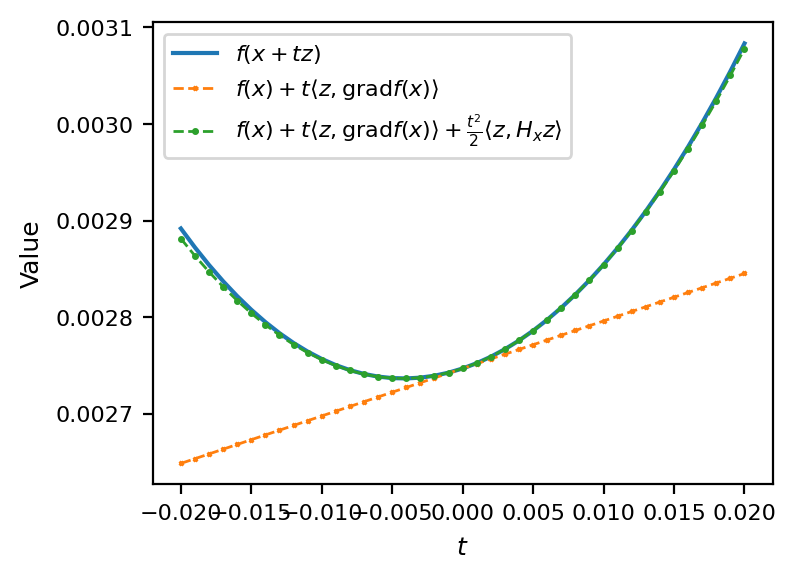

In [263]:
plt.figure(dpi=200, figsize=(4,3))

plt.plot(ts, cost_function_t, label=r"$f(x + t z)$")
plt.plot(ts, first_order_t, '--x', markersize=1.5, linewidth=1, label=r"$f(x) + t \langle z, \mathrm{grad} f(x) \rangle$")
plt.plot(ts, second_order_t, '--o', markersize=1.5, linewidth=1, label=r"$f(x) + t \langle z, \mathrm{grad} f(x) \rangle + \frac{t^2}{2} \langle z, H_x z \rangle$")

plt.xlabel(r'$t$')
plt.ylabel("Value")
plt.legend()

Sucesss! Both orders agree

# 2. Of the cost function defined on $T_x St (n, p) \to \mathrm{R}$

In [235]:
# The vectors x + tz from before were not in the riemannian manifold.
t = 0.005
z_vector = z1
print('X in manifold:', is_isometry(povm_isometry))
print('Z in tangent space:', is_in_tangent_space(z_vector, povm_isometry))
new_vector = povm_isometry + t * z_vector
print('New vector in manifold:', is_isometry(new_vector))
print("New vector in tangent space:", is_in_tangent_space(new_vector, povm_isometry))

X in manifold: True
Z in tangent space: True
New vector in manifold: False
New vector in tangent space: False


In [ ]:
# Need to bring back to manifold by means of a retraction.
def retraction(z:jnp.ndarray):
    return jax.scipy.linalg.polar(z)[0]

# Apply retraction
retracted_vector = retraction(new_vector)
print('New vector in manifold:', is_isometry(retracted_vector))
print("New vector in tangent space:", is_in_tangent_space(retracted_vector, povm_isometry))

New vector in manifold: True
New vector in tangent space: False


In [262]:
# Test if first order coincide: <rgrad, z>_x = Re(z.conj().T @ ∇f)
# With (euclidean gradient) ∇f = 2df/dx*
# With (riemannian gradient) rgrad = ∇f - x @ ∇f.T.conj() @ x

# Tangent Vector
t = 0.01
metric = "canonical"
# z_vector = povm_isometry + t * z1
z_vector = z1
print("In tangent space?", is_in_tangent_space(z_vector, povm_isometry))

# Compute the Euclidean and Riemannian gradients
grad_euclidean_povm_jax = gradf_povm(povm=povm_psd_init_jax) # 2df/dx (tensor)
grad_euclidean_povm = grad_euclidean_povm_jax.conj() # ∇f = 2df/dx* (tensor)
grad_euclidean_vector = tensor_to_isometry(tensor=grad_euclidean_povm, n=n, p=p) # ∇f(isometry)
if metric == "euclidean":
    grad_riemannian_vector = project_onto_tangent_space(x=povm_isometry, z=grad_euclidean_vector) # rgrad
else:
    grad_riemannian_vector = canonical_gradient(x=povm_isometry, z=grad_euclidean_vector) # rgrad
LHS = riemannian_metric(z_vector, grad_riemannian_vector, x=povm_isometry,metric=metric)
LHS2 = riemannian_metric(grad_riemannian_vector, z_vector, x=povm_isometry,metric=metric)

# Check symmetry
assert jnp.allclose(LHS, LHS2)
print('Riemannian inner product: <rgrad, z>_x:', LHS)

# Check with the euclidean:
tensor_shape = povm_psd_init_jax.shape
z_tensor = isometry_to_tensor(z_vector, tensor_shape=tensor_shape)
RHS = euclidean_inner_product_tensor(z_tensor, grad_euclidean_povm_jax)
print("Euclidean inner product: Re(z.conj().T @ ∇f)", RHS)
print("Are they the same?", jnp.allclose(LHS, RHS))

In tangent space? True
Using JAX power
Riemannian inner product: <rgrad, z>_x: 0.004918102981776811
Euclidean inner product: Re(z.conj().T @ ∇f) 0.004918102981776908
Are they the same? True


In [265]:
# Test the gradients we obtain
grad_1 = gradf_povm(povm=povm_psd_init_jax)
grad_2, _ = hvp(gradf_povm, x=povm_psd_init_jax, z=z_tensor)
jnp.allclose(grad_1, grad_2)

Using JAX power
Using JAX power


Array(True, dtype=bool)

In [378]:
def tangent_space_cost_function(x:Isometry, t:float, z:TangentVector, tensor_shape:tuple[int]):
    new_vector = retraction(x + t * z)
    return f_povm(isometry_to_tensor(new_vector, tensor_shape=tensor_shape))

def second_order_tangent(x:Tensor, z:Tensor, t:float, n:int, p:int):
    gradient_jax, Dgradient_z = hvp(gradf_povm, x=x, z=z) # 2df/dx, 2 Hxx dx + 2 Hx*x dx*
    gradient_mtrx = tensor_to_isometry(gradient_jax.conj(), n=n, p=p) # Dx = 2df/dx*
    x_mtrx = tensor_to_isometry(x, n=n, p=p)
    z_mtrx = tensor_to_isometry(z, n=n, p=p)
    extra_factor = jnp.trace(z_mtrx.conj().T @ z_mtrx @ x_mtrx.conj().T @ gradient_mtrx).real
    return (t**2 / 2) * (euclidean_inner_product_tensor(z, Dgradient_z) - extra_factor)

def riemannian_metric_with_hessian_vector(x:Tensor, z:Tensor, t:float, metric:str="canonical"):
    
    rhessian_vector_x = riemannian_hessian_vector_povm_jax(tangent_vector=z, kraus_tensor=kraus_tensor_init_jax, povm_psd=x, state_psd=state_psd_init_jax, indices_list=indices_list_2q, prob_matrix=prob_matrix_2q_sampled, metric=metric)
    z_mtrx = tensor_to_isometry(z, n=n, p=p)
    x_mtrx = tensor_to_isometry(x, n=n, p=p)
    return (t**2 / 2) * riemannian_metric(z_mtrx, 2 * rhessian_vector_x, x=x_mtrx, metric=metric)

def riemannian_metric_with_hessian_vector_mgst(x:Tensor, z:Tensor, t:float, n:int, p:int):
    rhessian_tensor, rgradient_tensor = riemannian_hessian_povm(
        K=kraus_init_mgst,
        A=np.array(x),
        B=state_psd_init_mgst,
        y=prob_matrix_2q_sampled,
        J=indices_list_2q,
        return_gradient=True
    )
    
    rhessian_matrix = rhessian_tensor.reshape(2 * n * p, 2 * n * p)
    z_and_z_conj = jnp.vstack((z, z.conj())).reshape(-1)
    hessian_z1 = rhessian_matrix @ z_and_z_conj
    hessian_z1 = hessian_z1[:n * p].reshape(n, p)  # we are getting only half of the vector

    x_mtrx = tensor_to_isometry(x, n=n, p=p)
    return (t**2 / 2) * riemannian_metric(2* hessian_z1, z1, x=x_mtrx, metric="canonical")

def approximation_tangent_space(x:Isometry, t:float, z:TangentVector, tensor_shape:tuple[int], riemannian:bool=True, metric:str="canonical", order:int = 1, use_mgst:bool=False):
    value = tangent_space_cost_function(x, 0, z, tensor_shape) # f(R(x + 0*v)) = f(x)
    # First order approximation
    x_tensor = isometry_to_tensor(isometry=x, tensor_shape=tensor_shape)
    z_tensor = isometry_to_tensor(isometry=z, tensor_shape=tensor_shape)
    grad_euclidean_jax = gradf_povm(povm=x_tensor) # 2df/dx (tensor)
    n, p = x.shape
    
    if riemannian:
        grad_riemannian, _ = gradient_and_operator_tensors_to_stiefel(gradient=grad_euclidean_jax.conj(), operator=x_tensor, n=n, p=p, metric=metric) # rgrad (matrix)
        value += t * riemannian_metric(z, grad_riemannian, x=x, metric=metric)
    else:
        value += t * euclidean_inner_product_tensor(z_tensor, grad_euclidean_jax)
        
    if order == 2:
        if riemannian:
            if use_mgst:
                value += riemannian_metric_with_hessian_vector_mgst(x_tensor, z_tensor, t=t, n=n, p=p)
            else:
                value += riemannian_metric_with_hessian_vector(x_tensor, z_tensor, t=t, metric=metric)
        else:
            value += second_order_tangent(x_tensor, z_tensor, t=t, n=n, p=p)
            
    return value

In [245]:
# Try now a second order approximation for the tangent space cost function
ts = np.arange(-0.02, 0.021, 0.001)
tensor_shape = povm_psd_init_jax.shape
tangent_cost_ts = [tangent_space_cost_function(povm_isometry, t, z_vector, tensor_shape=tensor_shape) for t in ts]

In [254]:
first_order_tangent_euc_ts = [approximation_tangent_space(x=povm_isometry, t=t, z=z_vector, tensor_shape=tensor_shape, riemannian=False) for t in ts]
first_order_tangent_riem_canonical_ts = [approximation_tangent_space(x=povm_isometry, t=t, z=z_vector, tensor_shape=tensor_shape, riemannian=True, metric="canonical") for t in ts]

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JA

In [258]:
jnp.allclose(jnp.array(first_order_tangent_euc_ts), jnp.array(first_order_tangent_riem_canonical_ts))

Array(True, dtype=bool)

In [ ]:
second_order_tangent_euc_ts = [approximation_tangent_space(x=povm_isometry, t=t, z=z_vector, tensor_shape=tensor_shape, riemannian=False, order=2) for t in ts]

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JA

In [379]:
second_order_tangent_riemannian_ts = [approximation_tangent_space(x=povm_isometry, t=t, z=z_vector, tensor_shape=tensor_shape, riemannian=True, metric="canonical", order=2) for t in ts]

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JA

In [377]:
second_order_tangent_riemannian_ts_conjugate = [approximation_tangent_space(x=povm_isometry, t=t, z=z_vector, tensor_shape=tensor_shape, riemannian=True, metric="canonical", order=2) for t in ts]

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JA

In [369]:
second_order_tangent_riemannian_mgst_ts = [approximation_tangent_space(x=povm_isometry, t=t, z=z_vector, tensor_shape=tensor_shape, riemannian=True, metric="canonical", order=2, use_mgst=True) for t in ts]

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power


In [375]:
jnp.allclose(jnp.array(second_order_tangent_riemannian_ts), jnp.array(second_order_tangent_euc_ts))

Array(False, dtype=bool)

In [372]:
jnp.allclose(jnp.array(second_order_tangent_riemannian_mgst_ts), jnp.array(second_order_tangent_euc_ts))

Array(True, dtype=bool)

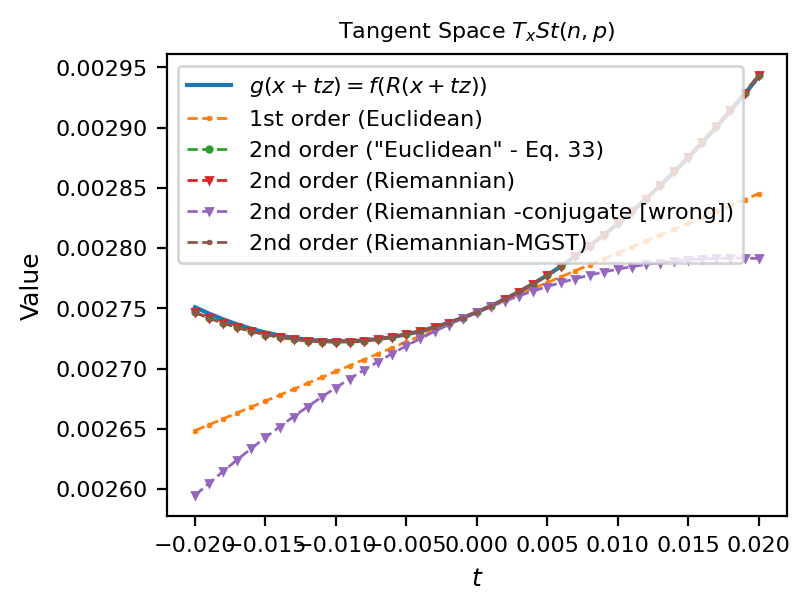

In [381]:
plt.figure(dpi=200, figsize=(4,3))
plt.plot(ts, tangent_cost_ts, label=r"$g(x + t z) = f(R(x + t z))$")
# plt.plot(ts, cost_function_t, label=r"$f(x + t z)$")
plt.plot(ts, first_order_tangent_euc_ts, '--x', markersize=1.5, linewidth=1, label=r"1st order (Euclidean)")
# plt.plot(ts, first_order_tangent_riem_canonical_ts, '--x', markersize=1.5, linewidth=1, label=r"$f(x) + t \langle z, \mathrm{rgrad} f(x) \rangle_x$ (Riemannian, Canonical)")
plt.plot(ts, second_order_tangent_euc_ts, '--o', markersize=2.0, linewidth=1, label=r'2nd order ("Euclidean" - Eq. 33)')

plt.plot(ts, second_order_tangent_riemannian_ts, '--v', markersize=2.0, linewidth=1, label=r"2nd order (Riemannian)")

plt.plot(ts, second_order_tangent_riemannian_ts_conjugate, '--v', markersize=2.0, linewidth=1, label=r"2nd order (Riemannian -conjugate [wrong])")

plt.plot(ts, second_order_tangent_riemannian_mgst_ts, '--x', markersize=1.5, linewidth=1, label=r"2nd order (Riemannian-MGST)")

# Euclidean
# First order: $f(x) + t \langle z, D_x \rangle_e$ 
# Second order: $f(x) + t \langle z, D_x \rangle_e + \frac{t^2}{2} (\langle z, H_x z \rangle_e - \langle z^\dagger z, x^\dagger D_x  \rangle_e)$

# Riemannian
# First order: $f(x) + t \langle z, \mathrm{rgrad} f(x) \rangle_x + \frac{t^2}{2}  \langle z, rhess_x z \rangle_x $
# Second order: $f(x) + t \langle z, \mathrm{rgrad} f(x) \rangle_x + \frac{t^2}{2}  \langle z, rhess_x z \rangle_x $

plt.title("Tangent Space $T_x St(n,p)$")
plt.xlabel(r'$t$')
plt.ylabel("Value")
plt.legend()
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()  # Adjust layout to prevent legend cutoff

# Conclusion:
A factor of two was missing!!!
Both the hessian obtained from the MGST and the one with jax were missing a factor of two. For the latter (jax), this is because we explicitely used `grad.conj()/2` = $df/dx*$.

**Note**: It is very important to remember where to conjugate and where not. For the euclidean derivation, we take $d_x(d_xf)$ and this gives rise to $H_{xx} dz + H_{x^*x} dz^*$. This means, we can take the `jvp` of the jax gradient $(2*df/dx)$ instead of taking the conjugate $(2*df/dx^*)$ if this is what we are expecting. Otherwise, taking: $d_x(d_x^*f)$ would give raise to the complex conjugate (also fine if we account for it).

On the other hand, for the Riemannian Hessian, we look at the relation between the riemannian-Hessian-vector product and the riemannian gradient (e.g. `Eq.(2.138)` of my master's thesis). With $\mathrm{Hess} f_x[z] = \nabla_z \mathrm{grad} f_x$ where $\mathrm{grad} f_x$ is the riemannian gradient (under some metric, e.g. euclidean or canonical). Together with the relation in `Eq.(4.32)` we can obtain the value for the riemannian-Hessian-vector product. It is important to notice here that the first term is the standard "directional derivative" (euclidean) of the Riemannian gradient (see `Eq.(4.37)`), and the Riemannian gradient depends on the Euclidean Gradient as shown by `Eq.(4.30)`, where the Euclidean gradient is given in `Corollary 4.0.1.` of of *An introduction to complex differentials and complex differentiability* - Hunger. so that the gradient has the direction of $df/dx^*$ (not $df/dx$)